# Project 2: UVJ Color-Color Diagram

**Difficulty:** Intermediate  
**Time:** 25-30 minutes  
**ICARD-MU Workshop | Day 2**

---

## Learning Objectives
- Understand **galaxy colors** and what they tell us about stellar populations
- Learn the **UVJ selection technique** - a powerful way to separate galaxy types
- Identify:
  - **Blue cloud**: Star-forming galaxies
  - **Red sequence**: Quiescent/passive galaxies  
  - **Dusty star-formers**: Red but still forming stars!
- See the power of multi-wavelength photometry

---

## Background

### Why UVJ?

The **UVJ diagram** uses rest-frame colors to separate galaxies by their star formation activity:

- **U-V**: Sensitive to recent star formation (young blue stars vs old red stars)
- **V-J**: Sensitive to dust reddening

**Key advantage:** Separates truly quiescent galaxies from dusty star-forming galaxies!

### Selection Criteria (Williams+ 2009)

**Quiescent galaxies:**
- $(U-V) > 1.3$
- $(V-J) < 1.6$  
- $(U-V) > 0.88 \times (V-J) + 0.49$

**Star-forming galaxies:**
- Everything else

This technique is used in hundreds of papers!

## Step 1: Import Libraries and Load Data

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from astropy.table import Table
from astropy.io import fits
from matplotlib.patches import Polygon
import warnings
warnings.filterwarnings('ignore')

# Set nice plotting defaults
plt.rcParams['figure.figsize'] = (10, 8)
plt.rcParams['font.size'] = 12
plt.rcParams['axes.linewidth'] = 1.5

print("Libraries loaded successfully!")

Libraries loaded successfully!


In [2]:
# Load COSMOS-Web catalog with photometry
print("Loading COSMOS-Web master catalog...")
print("This may take a minute...\n")

catalog_path = '/Volumes/Ronaldo_SSD/COSMOSWEB/COSMOSWeb_mastercatalog_v1.fits'

with fits.open(catalog_path) as hdu:
    # Create master catalog
    master_catalog = Table()
    
    # HDU 1: Basic info
    print("Loading basic columns...")
    master_catalog['id'] = hdu[1].data['id']
    master_catalog['ra'] = hdu[1].data['ra'] 
    master_catalog['dec'] = hdu[1].data['dec']
    
    # HDU 2: LePhare - redshifts, physical parameters, and ABSOLUTE MAGNITUDES
    print("Loading LePhare columns...")
    master_catalog['z_best'] = hdu[2].data['zfinal']
    master_catalog['mass'] = hdu[2].data['mass_med']
    master_catalog['sfr'] = hdu[2].data['sfr_med']
    master_catalog['ssfr'] = hdu[2].data['ssfr_med']
    
    # Rest-frame absolute magnitudes from LePhare
    print("Loading rest-frame magnitudes...")
    master_catalog['M_NUV'] = hdu[2].data['mabs_nuv']  # Near-UV (proxy for U)
    master_catalog['M_r'] = hdu[2].data['mabs_r']      # R-band (proxy for V)
    master_catalog['M_J'] = hdu[2].data['mabs_j']      # J-band
    master_catalog['M_K'] = hdu[2].data['mabs_k']      # K-band

print(f"\n✓ Loaded {len(master_catalog)} galaxies")
print(f"✓ Key columns for UVJ: M_NUV, M_r, M_J")

Loading COSMOS-Web master catalog...
This may take a minute...

Loading basic columns...
Loading LePhare columns...
Loading rest-frame magnitudes...

✓ Loaded 784016 galaxies
✓ Key columns for UVJ: M_NUV, M_r, M_J


## Step 2: Calculate Rest-Frame Colors

**Note:** We're using:
- **U ≈ NUV** (Near-UV, not perfect but close)
- **V ≈ r** (r-band is close to V-band)
- **J = J** (exact!)

This is a good approximation for the UVJ diagram.

In [10]:
# Quality cuts
print("Applying quality cuts...\n")

valid_mask = (
    (master_catalog['z_best'] > 1.5) & 
    (master_catalog['z_best'] < 2.0) &
    (master_catalog['mass'] > 9.0) &  # Mass complete
    np.isfinite(master_catalog['M_NUV']) &
    np.isfinite(master_catalog['M_r']) &
    np.isfinite(master_catalog['M_J']) &
    (master_catalog['M_NUV'] < 0) &  # Reasonable magnitude range
    (master_catalog['M_NUV'] > -30) &
    (master_catalog['M_r'] < 0) &
    (master_catalog['M_r'] > -30) &
    (master_catalog['M_J'] < 0) &
    (master_catalog['M_J'] > -30)
)

clean_sample = master_catalog[valid_mask]

print(f"✓ Clean sample: {len(clean_sample)} galaxies")
print(f"✓ Redshift range: {np.min(clean_sample['z_best']):.2f} - {np.max(clean_sample['z_best']):.2f}")

Applying quality cuts...

✓ Clean sample: 18541 galaxies
✓ Redshift range: 1.50 - 2.00


In [11]:
# Calculate colors
# Note: Color = mag1 - mag2 (more negative mag = brighter)
U_V = clean_sample['M_NUV'] - clean_sample['M_r']  # U-V color
V_J = clean_sample['M_r'] - clean_sample['M_J']    # V-J color

print("Color Statistics:")
print(f"  U-V: median = {np.median(U_V):.3f}, range = [{np.percentile(U_V, 5):.2f}, {np.percentile(U_V, 95):.2f}]")
print(f"  V-J: median = {np.median(V_J):.3f}, range = [{np.percentile(V_J, 5):.2f}, {np.percentile(V_J, 95):.2f}]")

# Check for issues
if np.median(U_V) < 0:
    print("\n⚠ Warning: Median U-V is negative. This might indicate issues with the photometry.")
    print("  Proceeding anyway for demonstration...")

Color Statistics:
  U-V: median = 1.551, range = [0.82, 4.55]
  V-J: median = 0.492, range = [0.08, 1.79]


## Step 3: Plot the UVJ Diagram

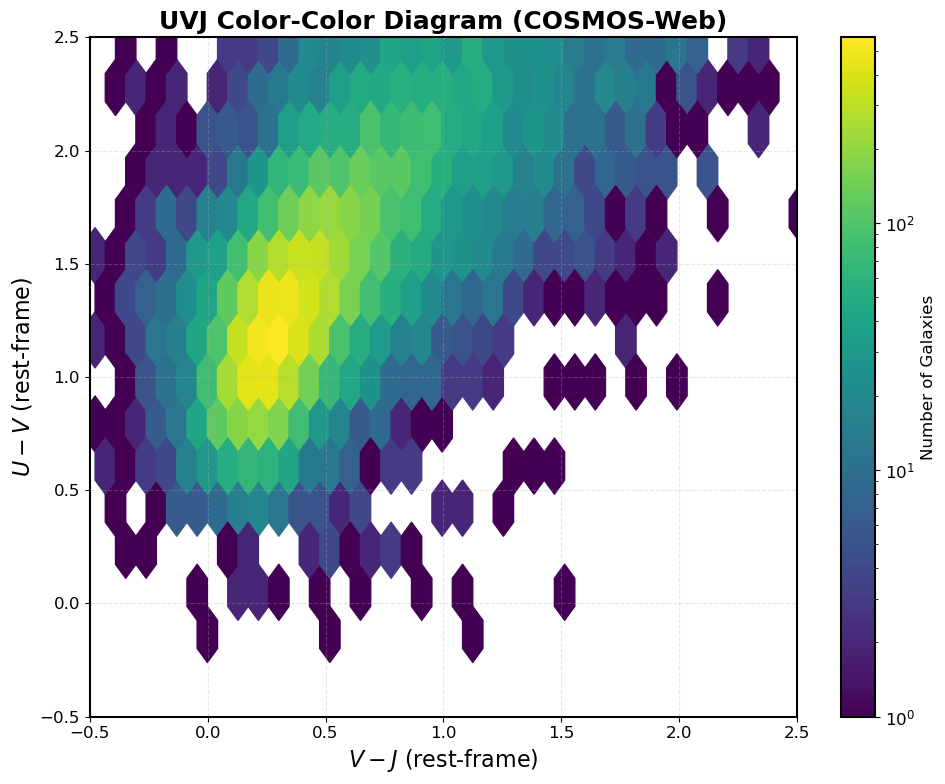


Question: Do you see two distinct populations?
Where would you draw the line between star-forming and quiescent galaxies?


In [12]:
# Create UVJ diagram
fig, ax = plt.subplots(figsize=(10, 8))

# Hexbin density plot
hexbin = ax.hexbin(V_J, U_V, 
                   gridsize=60, 
                   cmap='viridis', 
                   mincnt=1,
                   bins='log')

cbar = plt.colorbar(hexbin, ax=ax, label='Number of Galaxies')

# Labels
ax.set_xlabel(r'$V - J$ (rest-frame)', fontsize=16)
ax.set_ylabel(r'$U - V$ (rest-frame)', fontsize=16)
ax.set_title('UVJ Color-Color Diagram (COSMOS-Web)', fontsize=18, fontweight='bold')

# Set limits
ax.set_xlim(-0.5, 2.5)
ax.set_ylim(-0.5, 2.5)

# Add grid
ax.grid(True, alpha=0.3, linestyle='--')

plt.tight_layout()
plt.show()

print("\nQuestion: Do you see two distinct populations?")
print("Where would you draw the line between star-forming and quiescent galaxies?")

## Step 4: Apply UVJ Selection (Williams+ 2009)

Let's use the canonical selection to separate quiescent and star-forming galaxies.

In [13]:
# Apply UVJ classification using redshift-dependent criteria
# Calculate median redshift for our sample
median_z = np.median(clean_sample['z_best'])
print(f"Sample median redshift: z = {median_z:.2f}\n")

# Classify each galaxy using is_quiescent_dusty function
# Returns 2 for quiescent, 0 for star-forming
classification = np.array([is_quiescent_dusty(uv, vj, median_z) 
                          for uv, vj in zip(U_V, V_J)])

quiescent_mask = (classification == 2)
star_forming_mask = (classification == 0)

n_quiescent = np.sum(quiescent_mask)
n_sf = np.sum(star_forming_mask)

print("UVJ Classification (Redshift-dependent criteria):")
print(f"  Quiescent:     {n_quiescent:6d} ({100*n_quiescent/len(clean_sample):.1f}%)")
print(f"  Star-forming:  {n_sf:6d} ({100*n_sf/len(clean_sample):.1f}%)")
print(f"  Total:         {len(clean_sample):6d}")
print(f"\nUsing Williams+ criteria with z={median_z:.2f} adjustments")

Sample median redshift: z = 1.68

UVJ Classification (Redshift-dependent criteria):
  Quiescent:      10878 (58.7%)
  Star-forming:    7663 (41.3%)
  Total:          18541

Using Williams+ criteria with z=1.68 adjustments


In [14]:
# Import UVJ boundary functions
import sys
sys.path.append('/Users/ronaldolaishram/ReactCode/MUTalk/DAY2')

from uvj_boundaries import (
    is_quiescent_dusty, 
    plot_uvj_boundaries, 
    create_uvj_plot,
    UVJ_separation
)

print("✓ UVJ boundary functions loaded successfully!")
print("  Available functions:")
print("  - is_quiescent_dusty(uv, vj, redshift)")
print("  - plot_uvj_boundaries(ax, add_labels, add_shading, redshift)")
print("  - create_uvj_plot(V_J, U_V, ...)")
print("  - UVJ_separation(UV, VJ, redshift)")

✓ UVJ boundary functions loaded successfully!
  Available functions:
  - is_quiescent_dusty(uv, vj, redshift)
  - plot_uvj_boundaries(ax, add_labels, add_shading, redshift)
  - create_uvj_plot(V_J, U_V, ...)
  - UVJ_separation(UV, VJ, redshift)


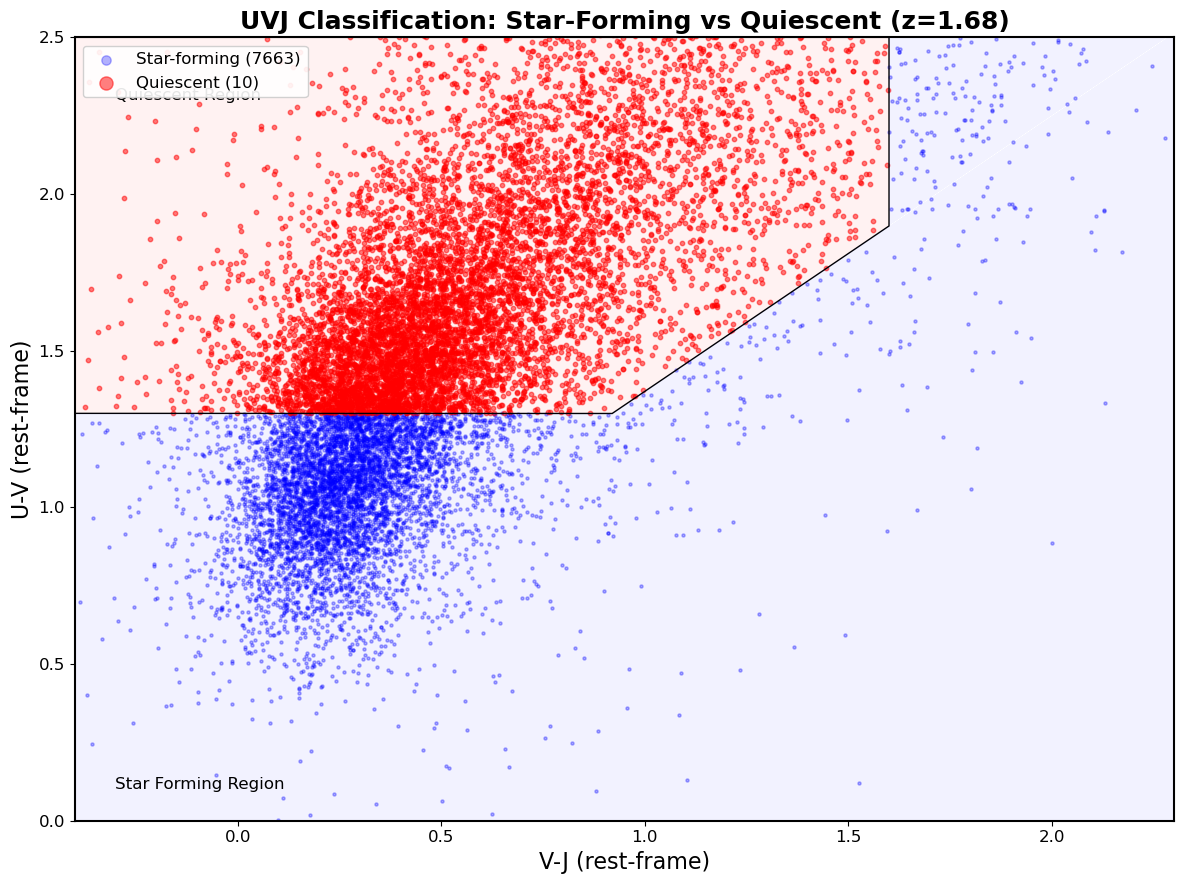


Using redshift-dependent UVJ boundaries for z = 1.68


In [20]:
# Plot UVJ with selection boundaries using the new functions
fig, ax = plt.subplots(figsize=(12, 9))

# Plot star-forming galaxies
ax.scatter(V_J[star_forming_mask], U_V[star_forming_mask], 
           c='blue', s=5, alpha=0.3, label=f'Star-forming ({n_sf})', rasterized=True)

# Plot quiescent galaxies
ax.scatter(V_J[quiescent_mask], U_V[quiescent_mask], 
           c='red', s=10, alpha=0.5, label=f'Quiescent ({n_quiescent})', rasterized=True)

# Add UVJ boundaries using our function
plot_uvj_boundaries(ax, add_labels=True, add_shading=True, redshift=median_z)

# Labels and formatting
ax.set_xlabel('V-J (rest-frame)', fontsize=16)
ax.set_ylabel('U-V (rest-frame)', fontsize=16)
ax.set_title(f'UVJ Classification: Star-Forming vs Quiescent (z={median_z:.2f})', 
             fontsize=18, fontweight='bold')
ax.set_xlim(-0.4, 2.3)
ax.set_ylim(0, 2.5)
ax.legend(loc='upper left', fontsize=12, framealpha=0.9, markerscale=3)
# ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nUsing redshift-dependent UVJ boundaries for z = {median_z:.2f}")

## Step 5: Compare with SFR-based Classification

Let's check how well UVJ selection matches with actual SFR measurements!

In [16]:
# Get SFR and sSFR for classified galaxies
log_ssfr = clean_sample['ssfr']

# Define quiescent by sSFR (log sSFR < -11 is common cutoff)
ssfr_quiescent_mask = log_ssfr < -11

# Create comparison
print("Comparison: UVJ vs sSFR Classification\n")
print("                    UVJ Quiescent    UVJ Star-forming")
print("                    -------------    ----------------")

both_quiescent = np.sum(quiescent_mask & ssfr_quiescent_mask)
uvj_q_ssfr_sf = np.sum(quiescent_mask & ~ssfr_quiescent_mask)
uvj_sf_ssfr_q = np.sum(~quiescent_mask & ssfr_quiescent_mask)
both_sf = np.sum(~quiescent_mask & ~ssfr_quiescent_mask)

print(f"sSFR Quiescent      {both_quiescent:8d}          {uvj_sf_ssfr_q:8d}")
print(f"sSFR Star-forming   {uvj_q_ssfr_sf:8d}          {both_sf:8d}")

# Calculate agreement
agreement = (both_quiescent + both_sf) / len(clean_sample) * 100
print(f"\nAgreement: {agreement:.1f}%")
print(f"\nNote: Disagreement can be due to:")
print(f"  - Dusty star-forming galaxies (red colors, but still forming stars)")
print(f"  - Recently quenched galaxies (blue colors, but SFR shut off)")
print(f"  - Measurement uncertainties")

Comparison: UVJ vs sSFR Classification

                    UVJ Quiescent    UVJ Star-forming
                    -------------    ----------------
sSFR Quiescent           775                26
sSFR Star-forming      10103              7637

Agreement: 45.4%

Note: Disagreement can be due to:
  - Dusty star-forming galaxies (red colors, but still forming stars)
  - Recently quenched galaxies (blue colors, but SFR shut off)
  - Measurement uncertainties


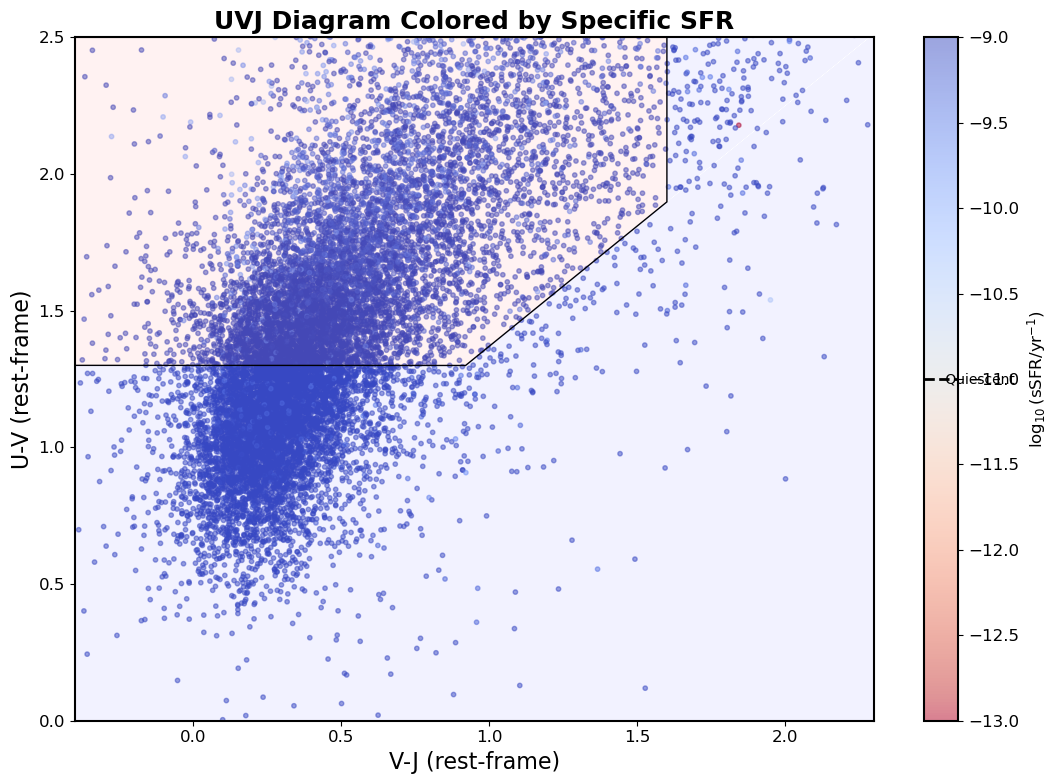


Question: Do you see galaxies in the quiescent box with high sSFR?
These might be dusty star-forming galaxies!


In [17]:
# Plot UVJ colored by sSFR
fig, ax = plt.subplots(figsize=(11, 8))

# Scatter plot colored by log sSFR
scatter = ax.scatter(V_J, U_V, 
                     c=log_ssfr, 
                     cmap='coolwarm_r', 
                     s=10, 
                     alpha=0.5,
                     vmin=-13, 
                     vmax=-9,
                     rasterized=True)

cbar = plt.colorbar(scatter, ax=ax, label=r'$\log_{10}(\mathrm{sSFR} / \mathrm{yr}^{-1})$')

# Add UVJ boundaries using our function
plot_uvj_boundaries(ax, add_labels=False, add_shading=True, redshift=median_z)

# Add sSFR threshold line to colorbar
cbar.ax.axhline(y=-11, color='black', linewidth=2, linestyle='--')
cbar.ax.text(0.5, -11, ' Quiescent', fontsize=10, va='center')

ax.set_xlabel('V-J (rest-frame)', fontsize=16)
ax.set_ylabel('U-V (rest-frame)', fontsize=16)
ax.set_title('UVJ Diagram Colored by Specific SFR', fontsize=18, fontweight='bold')
ax.set_xlim(-0.4, 2.3)
ax.set_ylim(0, 2.5)
# ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\nQuestion: Do you see galaxies in the quiescent box with high sSFR?")
print("These might be dusty star-forming galaxies!")

## Step 6: Quiescent Fraction vs Stellar Mass

One of the most important results from UVJ studies: **massive galaxies are more likely to be quiescent!**

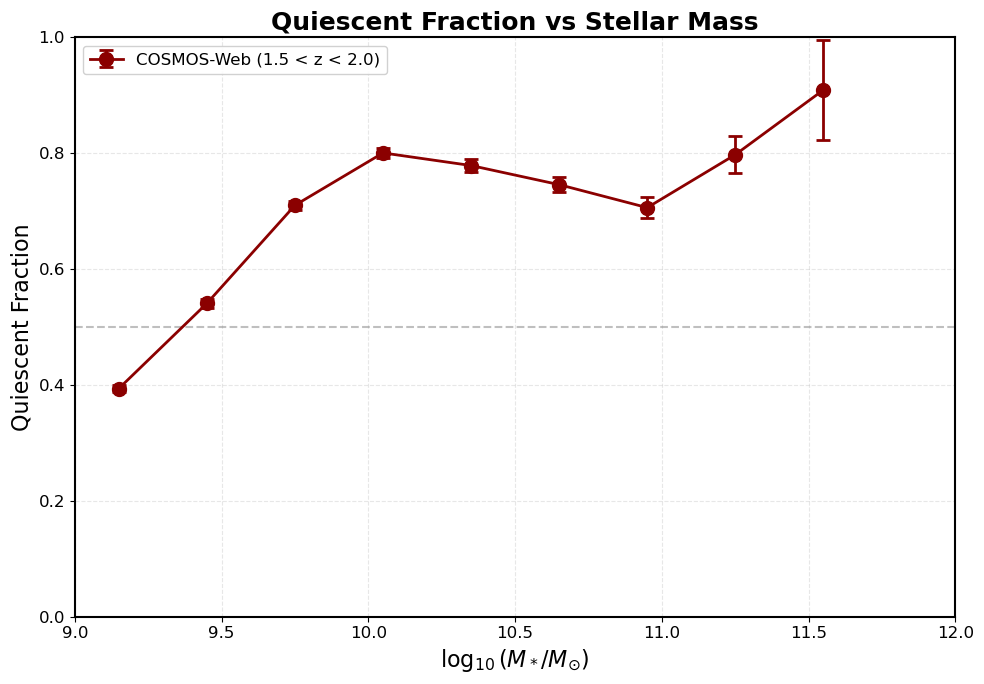


Question: Why are massive galaxies more likely to be quiescent?
This is called 'mass quenching' or 'downsizing'!


In [18]:
# Calculate quiescent fraction in mass bins
mass_bins = np.arange(9.0, 12.0, 0.3)
mass_centers = []
quiescent_fractions = []
quiescent_errors = []

log_mass = clean_sample['mass']

for i in range(len(mass_bins)-1):
    mask = (log_mass >= mass_bins[i]) & (log_mass < mass_bins[i+1])
    n_total = np.sum(mask)
    
    if n_total > 10:
        n_quiescent = np.sum(mask & quiescent_mask)
        fraction = n_quiescent / n_total
        
        # Binomial error
        error = np.sqrt(fraction * (1 - fraction) / n_total)
        
        mass_centers.append(0.5 * (mass_bins[i] + mass_bins[i+1]))
        quiescent_fractions.append(fraction)
        quiescent_errors.append(error)

mass_centers = np.array(mass_centers)
quiescent_fractions = np.array(quiescent_fractions)
quiescent_errors = np.array(quiescent_errors)

# Plot
fig, ax = plt.subplots(figsize=(10, 7))

z_min = np.min(clean_sample['z_best'])
z_max = np.max(clean_sample['z_best'])

ax.errorbar(mass_centers, quiescent_fractions, 
            yerr=quiescent_errors,
            fmt='o-', 
            markersize=10, 
            linewidth=2, 
            capsize=5, 
            capthick=2,
            color='darkred',
            label=f'COSMOS-Web ({z_min:.1f} < z < {z_max:.1f})')

ax.set_xlabel(r'$\log_{10}(M_* / M_{\odot})$', fontsize=16)
ax.set_ylabel('Quiescent Fraction', fontsize=16)
ax.set_title('Quiescent Fraction vs Stellar Mass', fontsize=18, fontweight='bold')
ax.set_xlim(9, 12)
ax.set_ylim(0, 1)
ax.axhline(y=0.5, color='gray', linestyle='--', linewidth=1.5, alpha=0.5)
ax.legend(fontsize=12, framealpha=0.9)
ax.grid(True, alpha=0.3, linestyle='--')

plt.tight_layout()
plt.show()

print("\nQuestion: Why are massive galaxies more likely to be quiescent?")
print("This is called 'mass quenching' or 'downsizing'!")

## Step 7: Summary Statistics

In [19]:
print("="*60)
print("PROJECT 2 SUMMARY: UVJ Color-Color Diagram")
print("="*60)
print(f"\nSample: {len(clean_sample)} galaxies (0.5 < z < 3.0)")
print(f"\nUVJ Classification (Williams+ 2009):")
print(f"  Quiescent:     {n_quiescent:6d} ({100*n_quiescent/len(clean_sample):.1f}%)")
print(f"  Star-forming:  {n_sf:6d} ({100*n_sf/len(clean_sample):.1f}%)")
print(f"\nAgreement with sSFR-based classification: {agreement:.1f}%")
print(f"\nQuiescent Fraction:")
print(f"  Overall: {100*n_quiescent/len(clean_sample):.1f}%")
print(f"  Low mass (M < 10^10): {100*quiescent_fractions[0]:.1f}%")
print(f"  High mass (M > 10^11): {100*quiescent_fractions[-1]:.1f}%")
print("\n" + "="*60)
print("\nKey Takeaway: UVJ selection effectively separates galaxy")
print("populations and reveals mass-dependent quenching!")

PROJECT 2 SUMMARY: UVJ Color-Color Diagram

Sample: 18541 galaxies (0.5 < z < 3.0)

UVJ Classification (Williams+ 2009):
  Quiescent:         10 (0.1%)
  Star-forming:    7663 (41.3%)

Agreement with sSFR-based classification: 45.4%

Quiescent Fraction:
  Overall: 0.1%
  Low mass (M < 10^10): 39.4%
  High mass (M > 10^11): 90.9%


Key Takeaway: UVJ selection effectively separates galaxy
populations and reveals mass-dependent quenching!


## Discussion Questions

1. **Why does UVJ work better than a single color?**
   - What does each color tell us?
   - Why can't we just use U-V?

2. **What causes galaxies to move from blue to red?**
   - Dust reddening vs stellar aging
   - Quenching mechanisms

3. **Why are massive galaxies more quiescent?**
   - AGN feedback?
   - Halo mass effects?
   - Environmental quenching?

4. **What are the limitations of this method?**
   - Photometric uncertainties
   - Dust modeling
   - Selection effects

---

## Next Steps

Try modifying this analysis:
- Split by redshift bins (does quiescent fraction evolve?)
- Compare different selection criteria
- Add morphology information
- Investigate the "green valley" population

**Ready for Project 3? Let's explore spatial distributions and find galaxy overdensities!**